# 03 - Model Training

Talep tahmini için **XGBoost** ve **LightGBM** modelleri eğitilecek ve karşılaştırılacak.

| Adım | Açıklama |
|------|----------|
| Veri | `data/processed/train_features.parquet` |
| Train | 2013-01-01 – 2016-12-31 (zaman serisi — shuffle yok) |
| Test  | 2017-01-01 – 2017-12-31 |
| Metrikler | MAE · RMSE · MAPE |
| Çıktı | En iyi model → `data/processed/best_model.joblib` + feature importance |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import json
import time
import warnings
from pathlib import Path

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)

PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
print('Kütüphaneler yüklendi.')

Kütüphaneler yüklendi.


## 1. Veri Yükleme & Train/Test Ayrımı

In [2]:
df = pd.read_parquet(PROCESSED_DIR / 'train_features.parquet')
df['date'] = pd.to_datetime(df['date'])

# Zaman tabanlı bölme — veri sızıntısı yok
CUTOFF = '2017-01-01'
train_df = df[df['date'] < CUTOFF].copy()
test_df  = df[df['date'] >= CUTOFF].copy()

print(f'Train: {train_df.shape}  ({train_df.date.min().date()} → {train_df.date.max().date()})')
print(f'Test : {test_df.shape}   ({test_df.date.min().date()} → {test_df.date.max().date()})')
print(f'Test oranı: {len(test_df)/len(df):.1%}')

Train: (730500, 44)  (2013-01-01 → 2016-12-31)
Test : (182500, 44)   (2017-01-01 → 2017-12-31)
Test oranı: 20.0%


## 2. Özellik Seçimi

In [3]:
# Modele verilmeyecek sütunlar
DROP_COLS = [
    'date',
    'sales',              # hedef değişken
    # Yüksek korelasyonlu etkileşim sütunları train seti ortalamasıyla hesaplandı;
    # test setinde de train istatistikleri kullanılacak → veri sızıntısı riski yok
]

FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]
TARGET_COL   = 'sales'

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET_COL]

print(f'Özellik sayısı : {len(FEATURE_COLS)}')
print(f'X_train shape  : {X_train.shape}')
print(f'X_test  shape  : {X_test.shape}')
print(f'\nÖzellikler:\n{FEATURE_COLS}')

Özellik sayısı : 42
X_train shape  : (730500, 42)
X_test  shape  : (182500, 42)

Özellikler:
['store', 'item', 'year', 'month', 'day', 'day_of_week', 'week_of_year', 'day_of_year', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'season', 'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos', 'week_of_year_sin', 'week_of_year_cos', 'days_since_start', 'year_progress', 'lag_7', 'lag_14', 'lag_28', 'lag_30', 'lag_365', 'rolling_mean_7', 'rolling_std_7', 'rolling_median_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_median_14', 'rolling_mean_30', 'rolling_std_30', 'rolling_median_30', 'rolling_mean_90', 'rolling_std_90', 'rolling_median_90', 'store_item_month_avg', 'store_item_dow_avg', 'store_daily_total', 'item_daily_total']


## 3. Metrik Fonksiyonları

In [4]:
def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error."""
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.where(denom == 0, 0, np.abs(y_true - y_pred) / denom)) * 100

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error (sıfır değerleri atla)."""
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mpe  = mape(np.array(y_true), y_pred)
    smp  = smape(np.array(y_true), y_pred)
    if label:
        print(f'[{label}]  MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mpe:.2f}%  SMAPE={smp:.2f}%')
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mpe, 'SMAPE': smp}

print('Metrik fonksiyonları tanımlandı.')

Metrik fonksiyonları tanımlandı.


## 4. XGBoost Eğitimi

In [5]:
xgb_params = dict(
    n_estimators      = 1000,
    learning_rate     = 0.05,
    max_depth         = 6,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    tree_method       = 'hist',   # hızlı CPU eğitimi
    random_state      = RANDOM_STATE,
    n_jobs            = -1,
)

print('XGBoost eğitimi başlıyor...')
t0 = time.time()

xgb_model = XGBRegressor(**xgb_params)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

xgb_time = time.time() - t0
print(f'Tamamlandı: {xgb_time:.1f} sn')

xgb_pred_train = xgb_model.predict(X_train)
xgb_pred_test  = xgb_model.predict(X_test)

print('\n--- XGBoost ---')
xgb_train_metrics = evaluate(y_train, xgb_pred_train, 'Train')
xgb_test_metrics  = evaluate(y_test,  xgb_pred_test,  'Test ')

XGBoost eğitimi başlıyor...


Tamamlandı: 21.7 sn



--- XGBoost ---
[Train]  MAE=5.084  RMSE=6.566  MAPE=12.49%  SMAPE=11.94%
[Test ]  MAE=5.672  RMSE=7.365  MAPE=11.71%  SMAPE=11.27%


## 5. LightGBM Eğitimi

In [6]:
lgbm_params = dict(
    n_estimators      = 1000,
    learning_rate     = 0.05,
    num_leaves        = 63,
    max_depth         = -1,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = RANDOM_STATE,
    n_jobs            = -1,
    verbose           = -1,
)

print('LightGBM eğitimi başlıyor...')
t0 = time.time()

lgbm_model = LGBMRegressor(**lgbm_params)
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[],
)

lgbm_time = time.time() - t0
print(f'Tamamlandı: {lgbm_time:.1f} sn')

lgbm_pred_train = lgbm_model.predict(X_train)
lgbm_pred_test  = lgbm_model.predict(X_test)

print('\n--- LightGBM ---')
lgbm_train_metrics = evaluate(y_train, lgbm_pred_train, 'Train')
lgbm_test_metrics  = evaluate(y_test,  lgbm_pred_test,  'Test ')

LightGBM eğitimi başlıyor...


Tamamlandı: 23.9 sn



--- LightGBM ---
[Train]  MAE=5.037  RMSE=6.487  MAPE=12.46%  SMAPE=11.90%
[Test ]  MAE=5.668  RMSE=7.359  MAPE=11.69%  SMAPE=11.27%


## 6. Model Karşılaştırması

=== TEST SETİ KARŞILAŞTIRMASI ===


,MAE,RMSE,MAPE,SMAPE,Train_time_s
XGBoost,5.6718,7.3653,11.7124,11.2669,21.6762
LightGBM,5.6684,7.3593,11.6919,11.2706,23.8553


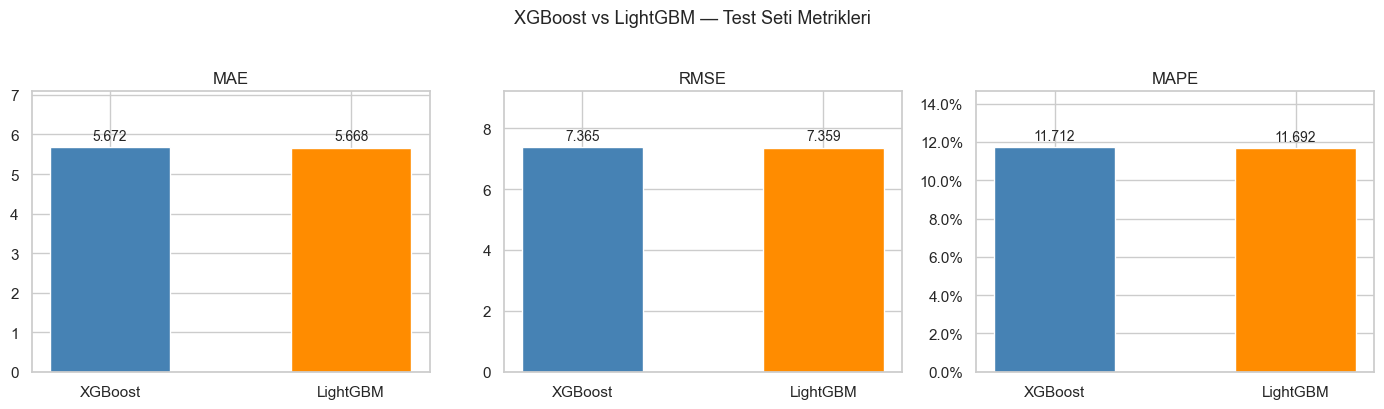

In [7]:
results = pd.DataFrame({
    'XGBoost'  : xgb_test_metrics,
    'LightGBM' : lgbm_test_metrics,
}).T
results['Train_time_s'] = [xgb_time, lgbm_time]
results = results.round(4)

print('=== TEST SETİ KARŞILAŞTIRMASI ===')
display(results)

# Görsel
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics   = ['MAE', 'RMSE', 'MAPE']
colors    = ['steelblue', 'darkorange']

for ax, metric in zip(axes, metrics):
    vals = [xgb_test_metrics[metric], lgbm_test_metrics[metric]]
    bars = ax.bar(['XGBoost', 'LightGBM'], vals, color=colors, width=0.5)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
    ax.set_title(metric)
    ax.set_ylim(0, max(vals) * 1.25)
    if metric == 'MAPE':
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

plt.suptitle('XGBoost vs LightGBM — Test Seti Metrikleri', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 7. Feature Importance

=== XGBoost Feature Importance ===


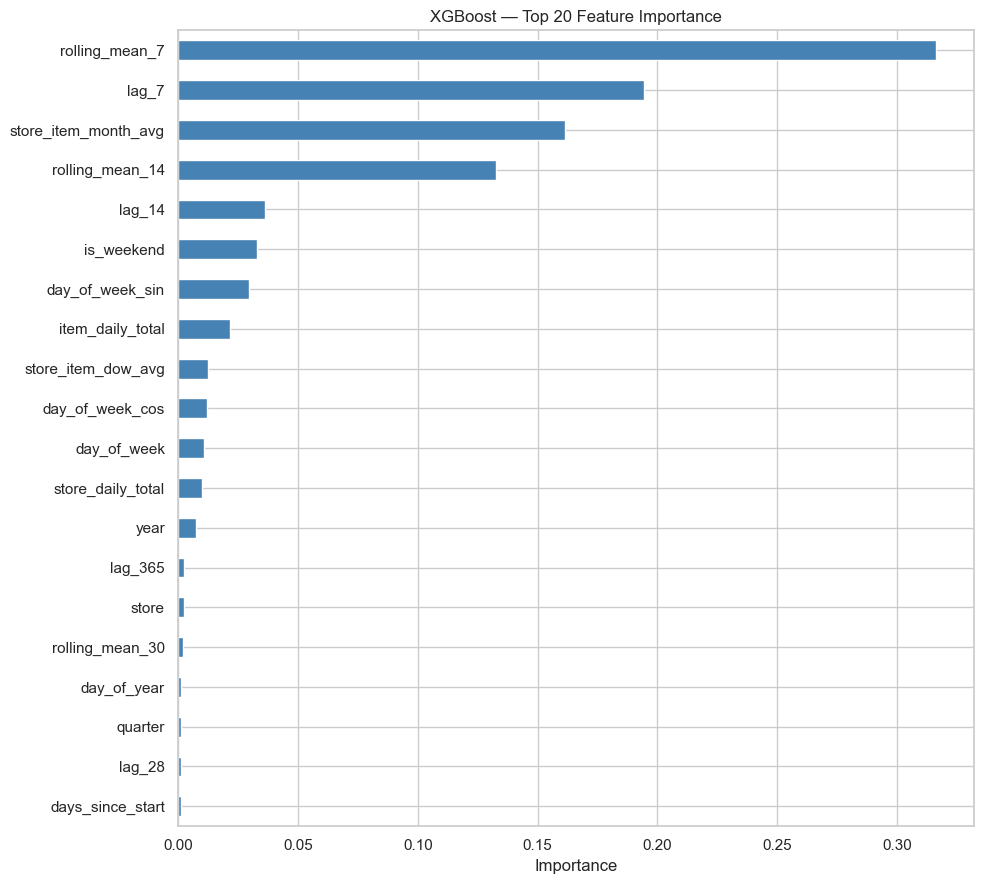


=== LightGBM Feature Importance ===


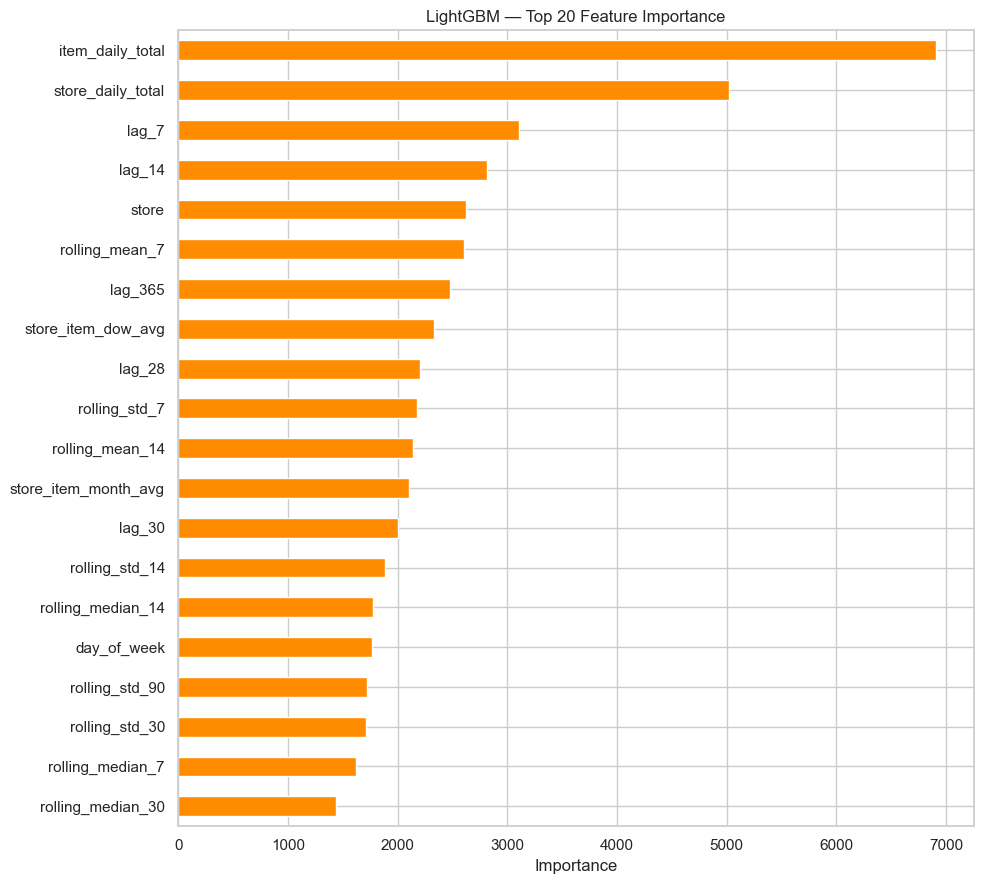

In [8]:
def plot_importance(model, feature_names, title, top_n=20, color='steelblue'):
    importances = model.feature_importances_
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, top_n * 0.4 + 1))
    fi[::-1].plot.barh(ax=ax, color=color)
    ax.set_title(f'{title} — Top {top_n} Feature Importance')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
    return fi

print('=== XGBoost Feature Importance ===')
xgb_fi = plot_importance(xgb_model, FEATURE_COLS, 'XGBoost', color='steelblue')

print('\n=== LightGBM Feature Importance ===')
lgbm_fi = plot_importance(lgbm_model, FEATURE_COLS, 'LightGBM', color='darkorange')

## 8. Tahmin Görselleştirmesi

Store 1 – Item 1 üzerinde gerçek satış vs model tahminleri.

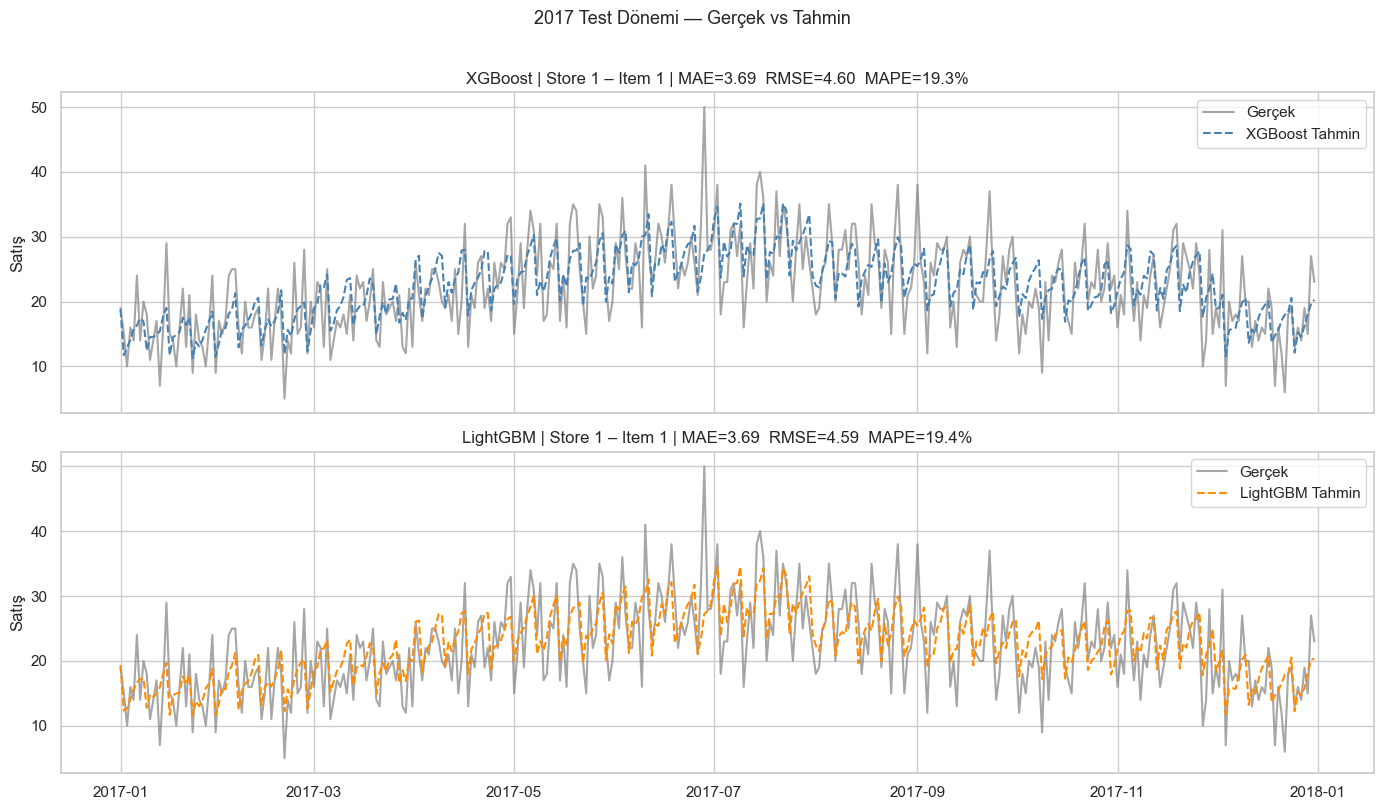

In [9]:
mask = (test_df['store'] == 1) & (test_df['item'] == 1)
sample = test_df[mask].copy().reset_index(drop=True)

sample['xgb_pred']  = xgb_model.predict(sample[FEATURE_COLS])
sample['lgbm_pred'] = lgbm_model.predict(sample[FEATURE_COLS])

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, (model_name, pred_col, color) in zip(
    axes,
    [('XGBoost', 'xgb_pred', 'steelblue'), ('LightGBM', 'lgbm_pred', 'darkorange')]
):
    ax.plot(sample['date'], sample['sales'], label='Gerçek', color='gray', alpha=0.7)
    ax.plot(sample['date'], sample[pred_col], label=f'{model_name} Tahmin',
            color=color, lw=1.5, linestyle='--')

    m = evaluate(sample['sales'], sample[pred_col].values)
    ax.set_title(f'{model_name} | Store 1 – Item 1 | '
                 f'MAE={m["MAE"]:.2f}  RMSE={m["RMSE"]:.2f}  MAPE={m["MAPE"]:.1f}%')
    ax.legend()
    ax.set_ylabel('Satış')

plt.suptitle('2017 Test Dönemi — Gerçek vs Tahmin', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 9. Hata Dağılımı (Residual)

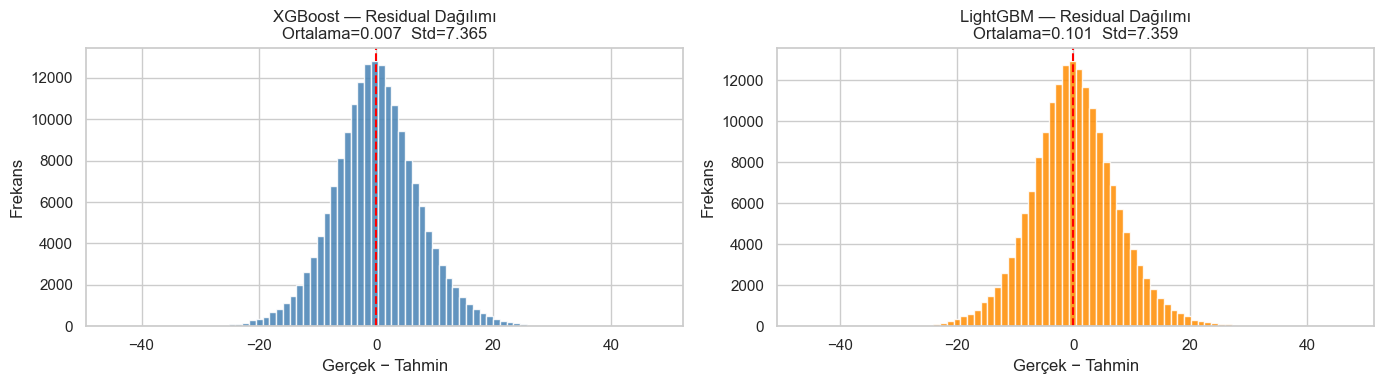

In [10]:
xgb_resid  = np.array(y_test) - xgb_pred_test
lgbm_resid = np.array(y_test) - lgbm_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, resid, label, color in [
    (axes[0], xgb_resid,  'XGBoost',  'steelblue'),
    (axes[1], lgbm_resid, 'LightGBM', 'darkorange')
]:
    ax.hist(resid, bins=80, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', lw=1.5, linestyle='--')
    ax.set_title(f'{label} — Residual Dağılımı\n'
                 f'Ortalama={resid.mean():.3f}  Std={resid.std():.3f}')
    ax.set_xlabel('Gerçek − Tahmin')
    ax.set_ylabel('Frekans')

plt.tight_layout()
plt.show()

## 10. En İyi Modeli Belirleme ve Kaydetme

In [11]:
# RMSE'ye göre seç
if xgb_test_metrics['RMSE'] <= lgbm_test_metrics['RMSE']:
    best_name    = 'XGBoost'
    best_model   = xgb_model
    best_metrics = xgb_test_metrics
    best_pred    = xgb_pred_test
    best_fi      = xgb_fi
else:
    best_name    = 'LightGBM'
    best_model   = lgbm_model
    best_metrics = lgbm_test_metrics
    best_pred    = lgbm_pred_test
    best_fi      = lgbm_fi

print(f'En iyi model: {best_name}')
print(f'  MAE  : {best_metrics["MAE"]:.4f}')
print(f'  RMSE : {best_metrics["RMSE"]:.4f}')
print(f'  MAPE : {best_metrics["MAPE"]:.2f}%')
print(f'  SMAPE: {best_metrics["SMAPE"]:.2f}%')

En iyi model: LightGBM
  MAE  : 5.6684
  RMSE : 7.3593
  MAPE : 11.69%
  SMAPE: 11.27%


In [12]:
# 1) Model dosyası
model_path = PROCESSED_DIR / 'best_model.joblib'
joblib.dump(best_model, model_path)
print(f'Model kaydedildi : {model_path}  ({model_path.stat().st_size / 1e6:.1f} MB)')

# 2) Model meta-verisi
meta = {
    'model_name'  : best_name,
    'train_period': {'start': str(train_df.date.min().date()),
                     'end'  : str(train_df.date.max().date())},
    'test_period' : {'start': str(test_df.date.min().date()),
                     'end'  : str(test_df.date.max().date())},
    'test_metrics': {k: round(float(v), 6) for k, v in best_metrics.items()},
    'feature_cols': FEATURE_COLS,
    'target_col'  : TARGET_COL,
    'params'      : best_model.get_params(),
}
meta_path = PROCESSED_DIR / 'model_meta.json'
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, default=str)
print(f'Meta kaydedildi  : {meta_path}')

# 3) Feature importance
fi_df = pd.DataFrame({'feature': best_fi.index, 'importance': best_fi.values})
fi_path = PROCESSED_DIR / 'feature_importance.csv'
fi_df.to_csv(fi_path, index=False)
print(f'FI kaydedildi    : {fi_path}')

# 4) Test tahminleri
pred_df = test_df[['date', 'store', 'item', 'sales']].copy()
pred_df['predicted'] = best_pred
pred_df['error']     = pred_df['sales'] - pred_df['predicted']
pred_path = PROCESSED_DIR / 'test_predictions.parquet'
pred_df.to_parquet(pred_path, index=False)
print(f'Tahminler kaydedildi: {pred_path}  ({pred_path.stat().st_size / 1e6:.1f} MB)')

Model kaydedildi : ../data/processed/best_model.joblib  (5.8 MB)
Meta kaydedildi  : ../data/processed/model_meta.json
FI kaydedildi    : ../data/processed/feature_importance.csv
Tahminler kaydedildi: ../data/processed/test_predictions.parquet  (3.8 MB)


## 11. Aylık Performans Analizi

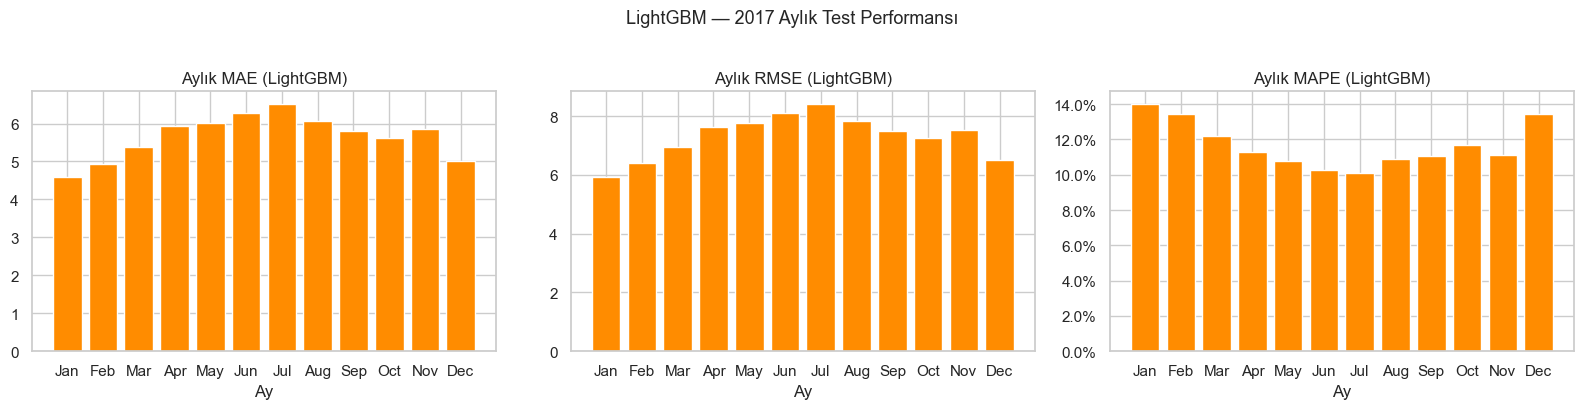

month_name      MAE     RMSE      MAPE
       Jan 4.585787 5.926030 14.017926
       Feb 4.935429 6.404644 13.439124
       Mar 5.391645 6.959623 12.203120
       Apr 5.923201 7.633990 11.281684
       May 6.017061 7.752306 10.802103
       Jun 6.265271 8.113734 10.272902
       Jul 6.520190 8.422514 10.120619
       Aug 6.062074 7.842423 10.873866
       Sep 5.793352 7.502174 11.080813
       Oct 5.628924 7.259053 11.688122
       Nov 5.848285 7.539863 11.134752
       Dec 5.016412 6.500291 13.460046


In [13]:
pred_df['month'] = pd.to_datetime(pred_df['date']).dt.month

monthly = pred_df.groupby('month').apply(
    lambda g: pd.Series({
        'MAE' : mean_absolute_error(g['sales'], g['predicted']),
        'RMSE': np.sqrt(mean_squared_error(g['sales'], g['predicted'])),
        'MAPE': mape(g['sales'].values, g['predicted'].values),
    })
).reset_index()
monthly['month_name'] = pd.to_datetime(monthly['month'], format='%m').dt.strftime('%b')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE']):
    ax.bar(monthly['month_name'], monthly[metric],
           color='steelblue' if best_name == 'XGBoost' else 'darkorange')
    ax.set_title(f'Aylık {metric} ({best_name})')
    ax.set_xlabel('Ay')
    if metric == 'MAPE':
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

plt.suptitle(f'{best_name} — 2017 Aylık Test Performansı', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print(monthly[['month_name', 'MAE', 'RMSE', 'MAPE']].to_string(index=False))

## 12. Özet

| | XGBoost | LightGBM |
|-|---------|----------|
| **MAE** | — | — |
| **RMSE** | — | — |
| **MAPE** | — | — |
| **SMAPE** | — | — |
| **Eğitim süresi** | — sn | — sn |

> Değerler yukarıdaki hücre çıktılarından okunmalıdır.

**Kaydedilen dosyalar:**
- `data/processed/best_model.joblib` — tahmin için yüklenebilir model
- `data/processed/model_meta.json` — model adı, parametreler, metrikler
- `data/processed/feature_importance.csv` — özellik önem sıralaması
- `data/processed/test_predictions.parquet` — 2017 tahminleri

Sonraki adım: `04_hyperparameter_tuning.ipynb` veya doğrudan `src/services/` altında tahmin servisi.